In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Feature Correlation Heatmap

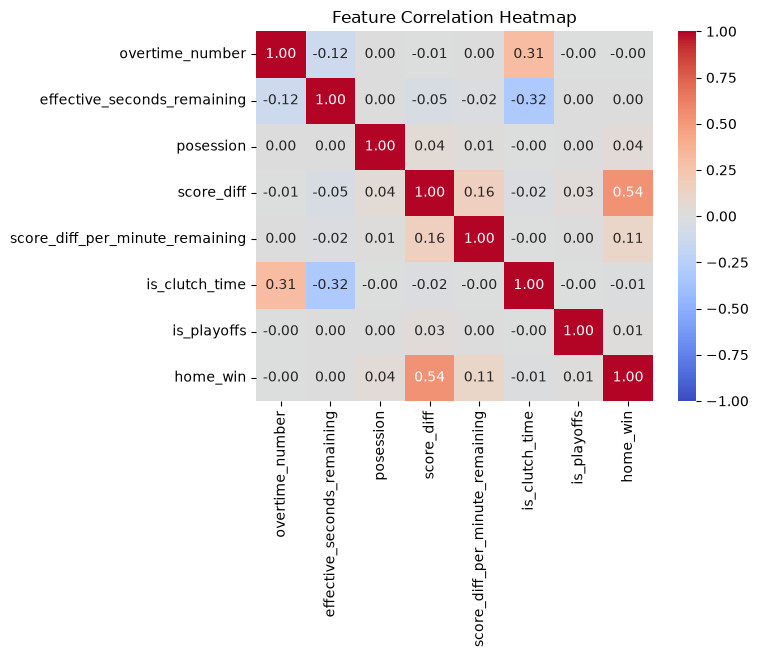

In [2]:
from config import TRAINING_FILE
df = pd.read_csv(TRAINING_FILE)

FEATURE_COLUMNS = [
    "overtime_number",
    "effective_seconds_remaining",
    "posession", # 1 if home team has possession, 0 if away team has possession
    "score_diff",
    "score_diff_per_minute_remaining",
    "is_clutch_time",
    "is_playoffs",
    "home_win",
]

feature_rows = df[FEATURE_COLUMNS].copy()
sns.heatmap(feature_rows.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title("Feature Correlation Heatmap")
plt.show()



C:\Users\long3\AppData\Local\Temp\ipykernel_16892\236185093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y='score_diff', data=feature_rows, palette='Set2')


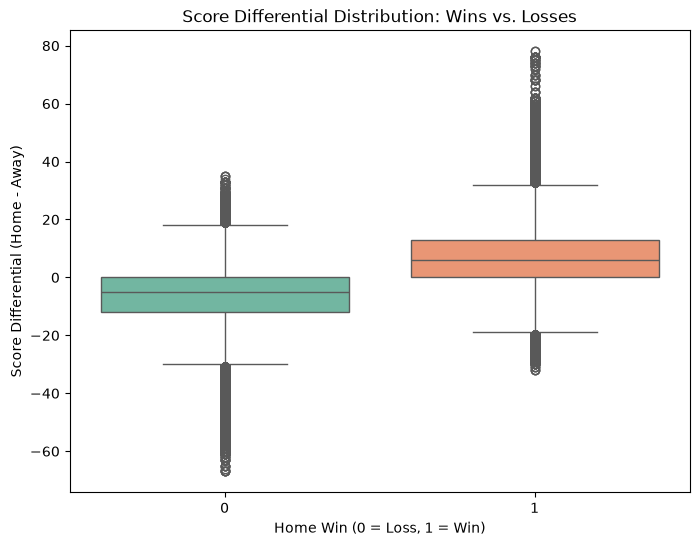

In [5]:
plt.figure(figsize=(8, 6))

# X is your label (0 or 1), Y is the feature you want to inspect
sns.boxplot(x='home_win', y='score_diff', data=feature_rows, palette='Set2')

plt.title("Score Differential Distribution: Wins vs. Losses")
plt.xlabel("Home Win (0 = Loss, 1 = Win)")
plt.ylabel("Score Differential (Home - Away)")
plt.show()

# Score Differential vs. Time Remaining

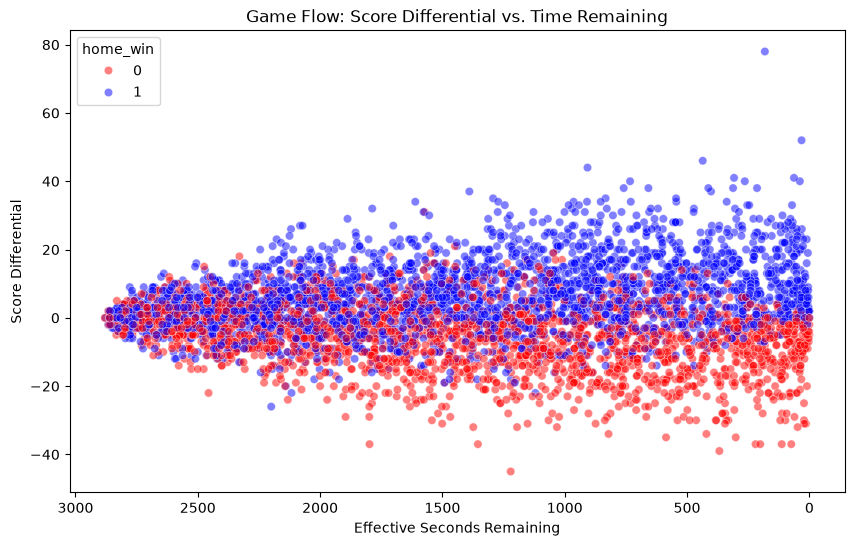

In [6]:
plt.figure(figsize=(10, 6))

# Sample 5,000 random rows so the chart doesn't get overcrowded
sample_df = feature_rows.sample(n=5000, random_state=42)

# Plot time on the X-axis and score difference on the Y-axis
# Hue colors the dots based on whether the home team ultimately won
sns.scatterplot(
    x='effective_seconds_remaining', 
    y='score_diff', 
    hue='home_win', 
    data=sample_df, 
    alpha=0.5, # Makes dots slightly transparent
    palette=['red', 'blue'] # Red for loss, Blue for win
)

# Invert the X-axis so time counts down from left to right (e.g., 2880 -> 0)
plt.gca().invert_xaxis()

plt.title("Game Flow: Score Differential vs. Time Remaining")
plt.xlabel("Effective Seconds Remaining")
plt.ylabel("Score Differential")
plt.show()

# score_diff distribution

<Axes: xlabel='score_diff', ylabel='Count'>

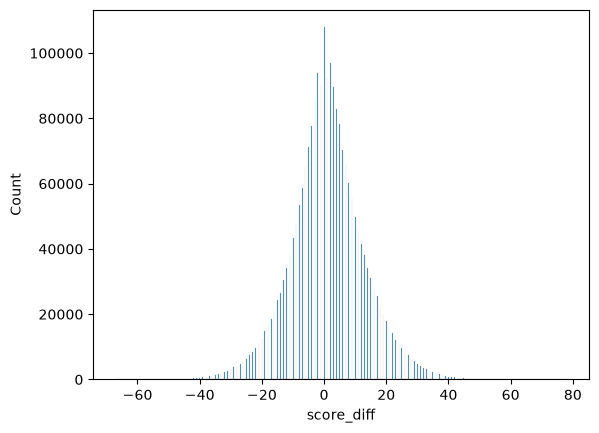

In [7]:
sns.histplot(data=feature_rows['score_diff'])